In [1]:
import torch
from torch import nn

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
import requests
import zipfile
from pathlib import Path

dataPath = Path("foodData/")
imagePath = dataPath / "pizzaSteakSushi"

if imagePath.is_dir():
    print("Folder already exists")
else:
    print(f"Did not find {imagePath}. Creating one....")
    imagePath.mkdir(parents=True,exist_ok=True)

    with open(dataPath / "pizzaSteakSushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading zip file")
        f.write(request.content)
    with zipfile.ZipFile(dataPath / "pizzaSteakSushi.zip", "r") as zipref:
        print("Extracting zip file...")
        zipref.extractall(imagePath)

Did not find foodData/pizzaSteakSushi. Creating one....
Extracting zip file...


In [5]:
trainDir = imagePath / "train"
testDir = imagePath / "test"

print(trainDir, testDir)

(PosixPath('foodData/pizzaSteakSushi/train'),
 PosixPath('foodData/pizzaSteakSushi/test'))

In [7]:
import os

def walkThroughDir(dirPath):
    for dirpath, dirnames, filenames in os.walk(dirPath):
        print(f"{len(dirnames)} directories, {len(filenames)} images in {dirpath}")
walkThroughDir(imagePath)

2 directories, 0 images in foodData/pizzaSteakSushi
3 directories, 0 images in foodData/pizzaSteakSushi/train
0 directories, 78 images in foodData/pizzaSteakSushi/train/pizza
0 directories, 72 images in foodData/pizzaSteakSushi/train/sushi
0 directories, 75 images in foodData/pizzaSteakSushi/train/steak
3 directories, 0 images in foodData/pizzaSteakSushi/test
0 directories, 25 images in foodData/pizzaSteakSushi/test/pizza
0 directories, 31 images in foodData/pizzaSteakSushi/test/sushi
0 directories, 19 images in foodData/pizzaSteakSushi/test/steak


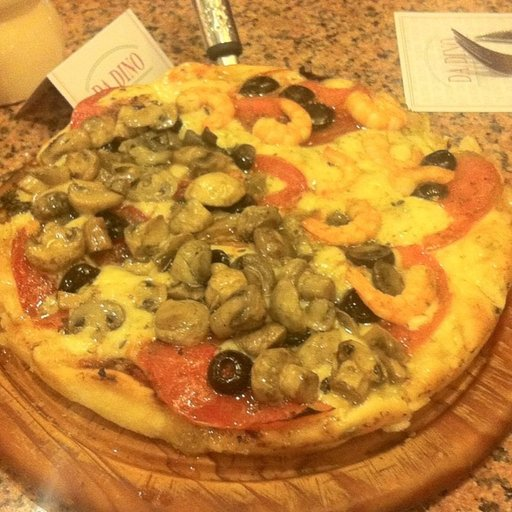

In [10]:
import random
from PIL import Image
random.seed(42)

imagePathList = list(imagePath.glob("*/*/*.jpg"))
randomImagePath = random.choice(imagePathList)
imageClass = randomImagePath.parent.stem

img = Image.open(randomImagePath)
img

Matplotlib is building the font cache; this may take a moment.


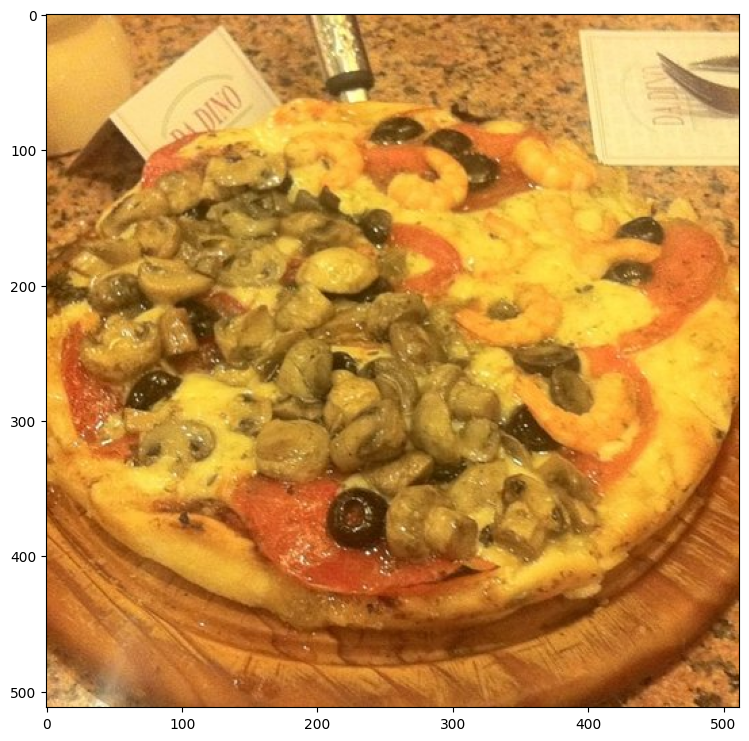

In [11]:
import numpy as np
import matplotlib.pyplot as plt

imgArray = np.asarray(img)
plt.figure(figsize=(12,9))
plt.imshow(imgArray)

In [12]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [15]:
dataTransforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [16]:
trainData = datasets.ImageFolder(root=trainDir, transform=dataTransforms,target_transform=None)
testData = datasets.ImageFolder(root=testDir, transform=dataTransforms)

In [17]:
classNames = trainData.classes

In [19]:
img, label = trainData[0][0], trainData[0][1]
print(img.shape)
print(type(label))

torch.Size([3, 64, 64])
<class 'int'>


In [21]:
imgPermute = img.permute(1,2,0) # HWC format
print(f"Original Shape: {img.shape}")
print(f"Permuted Shape: {imgPermute.shape}")

Original Shape: torch.Size([3, 64, 64])
Permuted Shape: torch.Size([64, 64, 3])


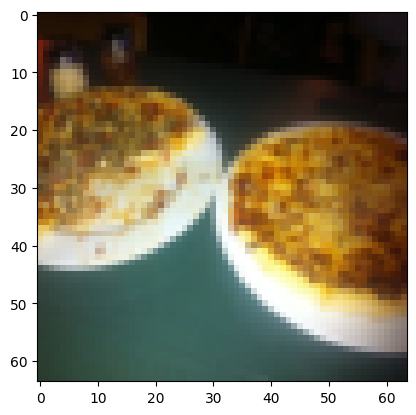

In [23]:
plt.imshow(imgPermute)

In [24]:
trainDataLoader = DataLoader(dataset=trainData, batch_size=1, num_workers=1,shuffle=True)
testDataLoader = DataLoader(dataset=testData, batch_size=1, num_workers=1, shuffle=False)

# FUCK it. Let's build an actual model

## Model 0 : TinyVGG without Augmentation

In [25]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

In [27]:
simpleTransform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

# Turn data/images into image dataset and use dataloader to create a wrapable iterator

trainDataset0 = datasets.ImageFolder(root=trainDir, transform=simpleTransform)
testDataset0 = datasets.ImageFolder(root=testDir, transform=simpleTransform)

trainDataLoader0 = DataLoader(dataset=trainDataset0, shuffle=True, num_workers=1, batch_size=BATCH_SIZE)
testDataLoader0 = DataLoader(dataset=testDataset0, shuffle=False, num_workers=1, batch_size=BATCH_SIZE)

In [ ]:
class Model0(nn.Module):
    